# Week 3 Assignment — Customer Intelligence System

## Dataset: Unsupervised Learning on Country Data

**Name:** Ashwani Kumar
**College:** MMDU
**Role:** Data Scientist Intern — Celebal Technology

**Week:** 3 — Classification, Ensemble & Clustering

---

### Objective
Develop a Customer Intelligence System using:
- Classification (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost)
- Ensemble Learning (Random Forest, Gradient Boosting, XGBoost, Stacking)
- Clustering (K-Means, DBSCAN) with PCA visualization

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, accuracy_score,
                             precision_score, recall_score,
                             f1_score, confusion_matrix,
                             classification_report)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported")

✅ All libraries imported


In [35]:
df = pd.read_csv('Country-data.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (167, 10)

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [36]:
# ── DATA CLEANING ────────────────────────────────────────────
print("Missing values:\n", df.isnull().sum())
df.drop_duplicates(inplace=True)
print("\nAfter cleaning shape:", df.shape)
print("\nBasic statistics:")
df.describe()

Missing values:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

After cleaning shape: (167, 10)

Basic statistics:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


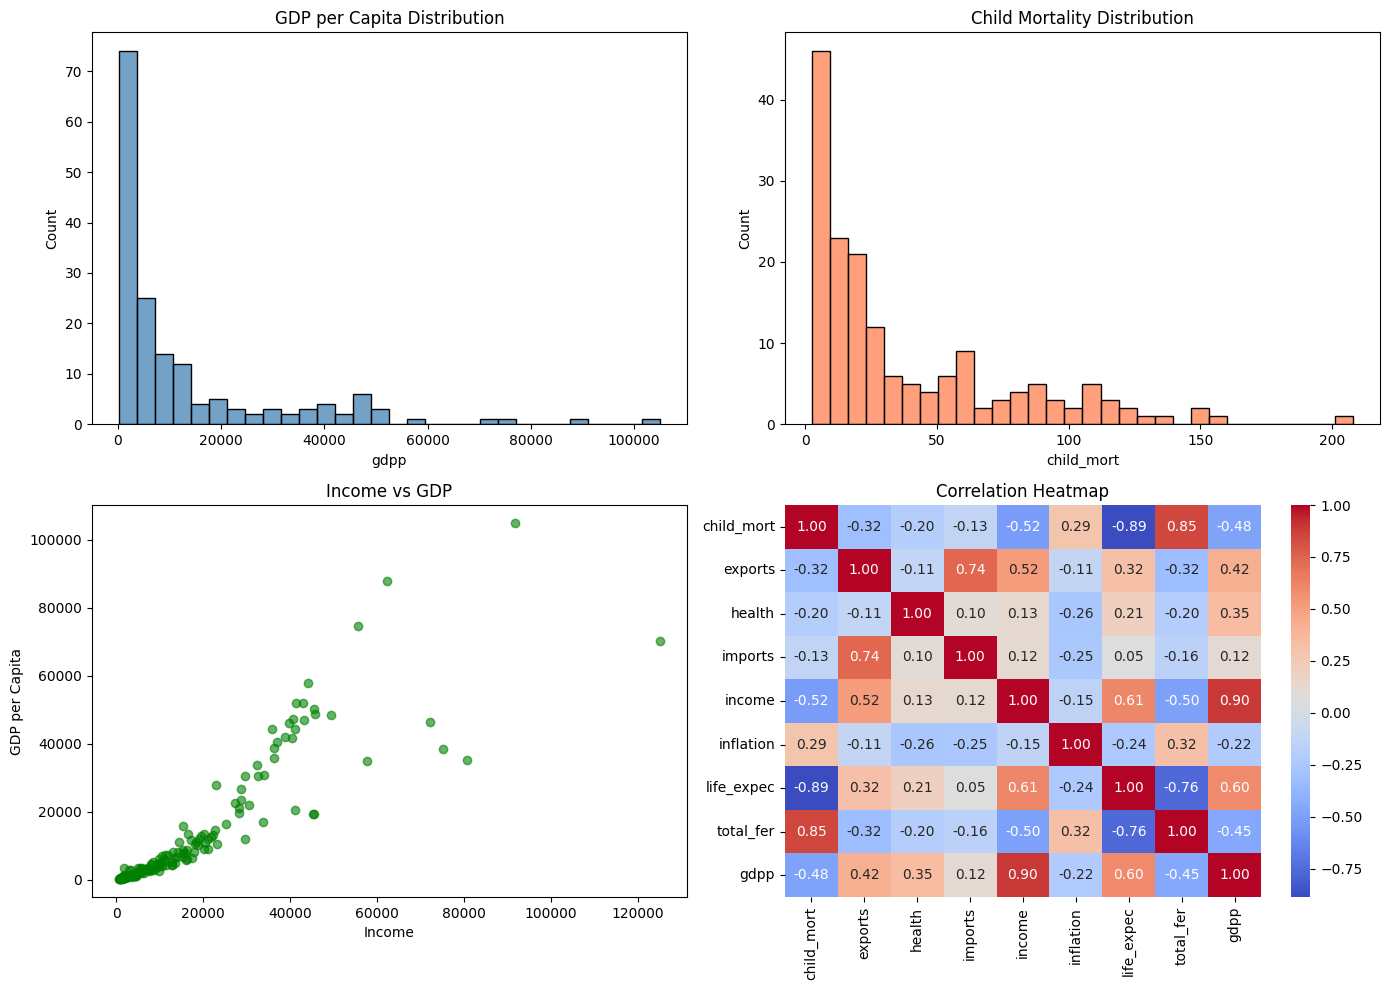

✅ EDA complete


In [37]:
# ── EDA ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — GDP per capita distribution
sns.histplot(df['gdpp'], bins=30, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('GDP per Capita Distribution')

# Plot 2 — Child mortality distribution
sns.histplot(df['child_mort'], bins=30, ax=axes[0,1], color='coral')
axes[0,1].set_title('Child Mortality Distribution')

# Plot 3 — Income vs GDP scatter
axes[1,0].scatter(df['income'], df['gdpp'], alpha=0.6, color='green')
axes[1,0].set_xlabel('Income')
axes[1,0].set_ylabel('GDP per Capita')
axes[1,0].set_title('Income vs GDP')

# Plot 4 — Correlation heatmap
numeric_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[numeric_cols].corr(), annot=True,
            fmt='.2f', cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()
print("✅ EDA complete")

In [38]:
# ── FEATURE ENGINEERING ──────────────────────────────────────
# Create a target column for classification
# Countries with high child_mort and low gdpp = 'underdeveloped'
# We use median as threshold to create binary labels

df['development_label'] = np.where(
    (df['child_mort'] > df['child_mort'].median()) &
    (df['gdpp'] < df['gdpp'].median()),
    1,  # underdeveloped
    0   # developed
)

print("Label distribution:")
print(df['development_label'].value_counts())
print("\n0 = Developed, 1 = Underdeveloped")
print("✅ Feature Engineering complete")

Label distribution:
development_label
0    98
1    69
Name: count, dtype: int64

0 = Developed, 1 = Underdeveloped
✅ Feature Engineering complete


In [39]:
# ── PREPARE X AND y ──────────────────────────────────────────
X = df[numeric_cols].drop(columns=['development_label'],
                           errors='ignore')
y = df['development_label']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("✅ Split + Scaling complete")

Train: (133, 9) | Test: (34, 9)
✅ Split + Scaling complete


In [40]:
# ── STACKING ENSEMBLE ────────────────────────────────────────
from sklearn.ensemble import StackingClassifier

# Base models
estimators = [
    ('rf',  RandomForestClassifier(n_estimators=50, random_state=42)),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss'))
]

# Meta model
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)
stacking.fit(X_train_sc, y_train)
stack_pred = stacking.predict(X_test_sc)

print("Stacking Classifier")
print(f"  Accuracy : {accuracy_score(y_test, stack_pred):.4f}")
print(f"  F1 Score : {f1_score(y_test, stack_pred):.4f}")
print("✅ Stacking complete")

Stacking Classifier
  Accuracy : 1.0000
  F1 Score : 1.0000
✅ Stacking complete


In [41]:
# ── CLASSIFICATION ───────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=42),
    'XGBoost'             : XGBClassifier(random_state=42,
                                          eval_metric='logloss')
}

results = {}
trained  = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)
    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall'   : round(recall_score(y_test, pred), 4),
        'F1 Score' : round(f1_score(y_test, pred), 4)
    }
    trained[name] = model
    print(f"\n{name}")
    print(f"  Accuracy : {results[name]['Accuracy']}")
    print(f"  F1 Score : {results[name]['F1 Score']}")

print("\n✅ Classification complete")


Logistic Regression
  Accuracy : 0.9706
  F1 Score : 0.9655

Decision Tree
  Accuracy : 1.0
  F1 Score : 1.0

Random Forest
  Accuracy : 1.0
  F1 Score : 1.0

Gradient Boosting
  Accuracy : 1.0
  F1 Score : 1.0

XGBoost
  Accuracy : 1.0
  F1 Score : 1.0

✅ Classification complete


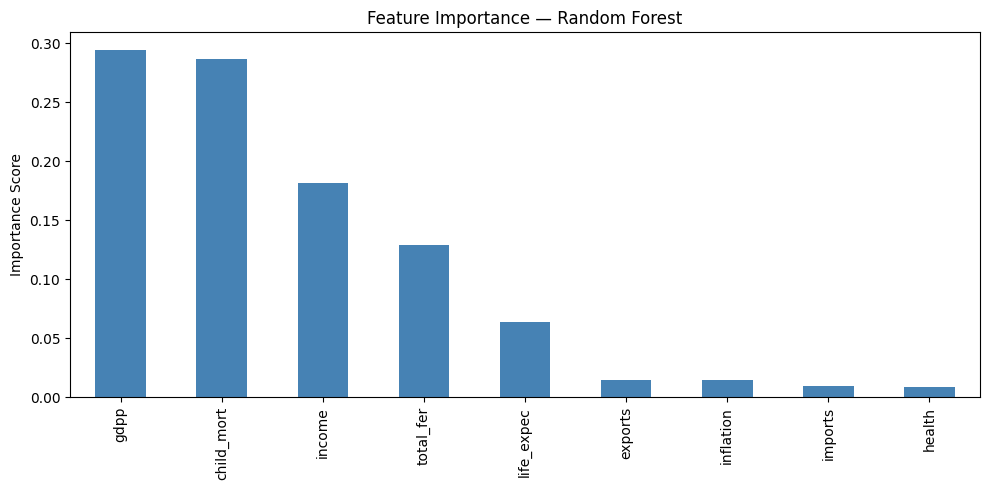

Most important feature: gdpp
✅ Feature Importance complete


In [42]:
# ── FEATURE IMPORTANCE (Random Forest) ───────────────────────
rf = trained['Random Forest']
importances = pd.Series(rf.feature_importances_,
                        index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("Most important feature:", importances.index[0])
print("✅ Feature Importance complete")

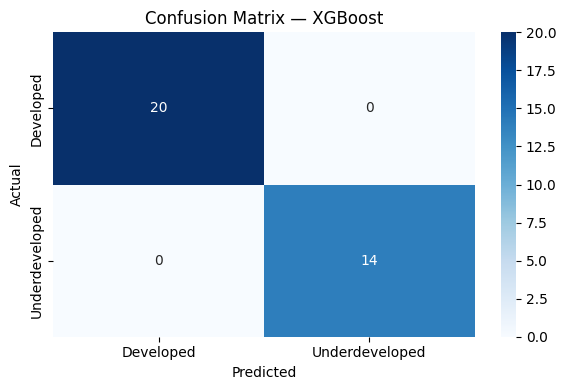


Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00        20
Underdeveloped       1.00      1.00      1.00        14

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



In [43]:
# ── CONFUSION MATRIX ─────────────────────────────────────────
best_pred = trained['XGBoost'].predict(X_test_sc)
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Developed','Underdeveloped'],
            yticklabels=['Developed','Underdeveloped'])
plt.title('Confusion Matrix — XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, best_pred,
      target_names=['Developed','Underdeveloped']))

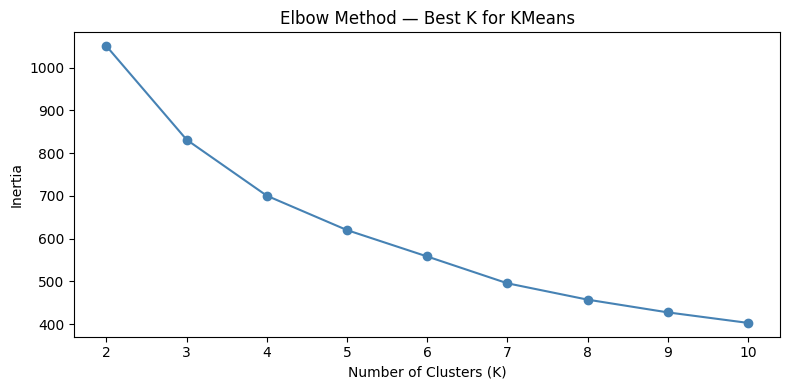

Silhouette Score (K=3): 0.2833
✅ K-Means complete


In [44]:
# ── K-MEANS CLUSTERING ───────────────────────────────────────
X_cluster = scaler.fit_transform(
    df[numeric_cols].drop(columns=['development_label'], errors='ignore')
)

# Elbow method to find best K
inertias = []
k_range  = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, marker='o', color='steelblue')
plt.title('Elbow Method — Best K for KMeans')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

# Train with best K
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_cluster)

score = silhouette_score(X_cluster, df['kmeans_cluster'])
print(f"Silhouette Score (K={best_k}): {score:.4f}")
print("✅ K-Means complete")

In [45]:
# ── DBSCAN CLUSTERING ────────────────────────────────────────
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_cluster)

print("DBSCAN cluster counts:")
print(df['dbscan_cluster'].value_counts().sort_index())
print("\nNote: -1 means outliers detected by DBSCAN")
print("✅ DBSCAN complete")

DBSCAN cluster counts:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

Note: -1 means outliers detected by DBSCAN
✅ DBSCAN complete


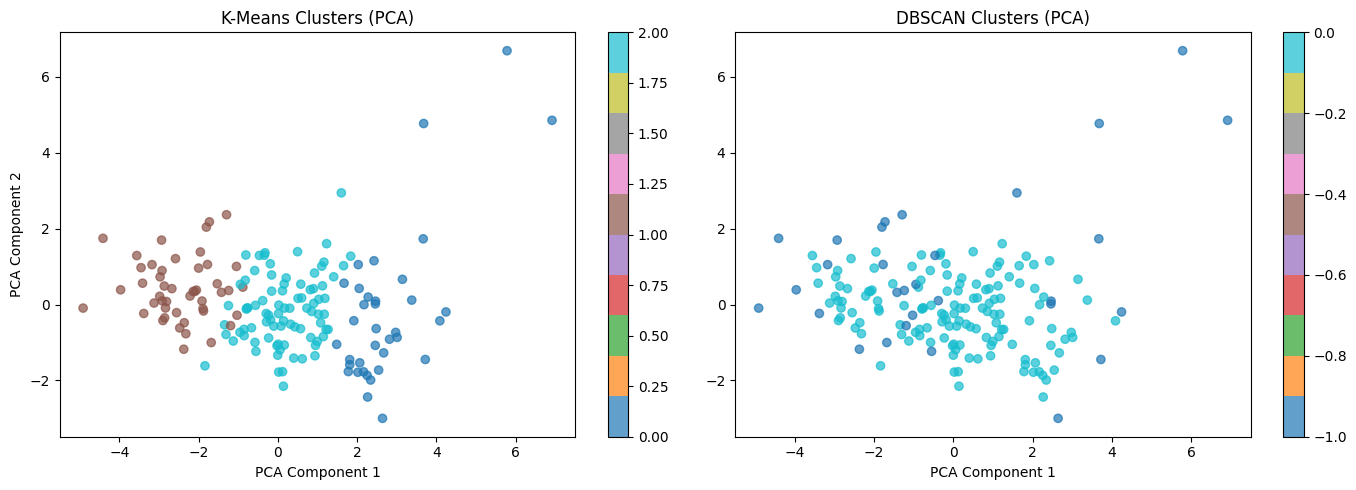

✅ PCA Visualization complete


In [46]:
# ── PCA VISUALIZATION ────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KMeans clusters
scatter1 = axes[0].scatter(X_pca[:,0], X_pca[:,1],
                            c=df['kmeans_cluster'],
                            cmap='tab10', alpha=0.7)
axes[0].set_title('K-Means Clusters (PCA)')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
plt.colorbar(scatter1, ax=axes[0])

# DBSCAN clusters
scatter2 = axes[1].scatter(X_pca[:,0], X_pca[:,1],
                            c=df['dbscan_cluster'],
                            cmap='tab10', alpha=0.7)
axes[1].set_title('DBSCAN Clusters (PCA)')
axes[1].set_xlabel('PCA Component 1')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()
print("✅ PCA Visualization complete")

Cluster Profiles:
                child_mort    income      gdpp  life_expec  inflation
kmeans_cluster                                                       
0                     5.00  45672.22  42494.44       80.13       2.67
1                    92.96   3942.40   1922.38       59.19      12.02
2                    21.93  12305.60   6486.45       72.81       7.60


<Figure size 1000x500 with 0 Axes>

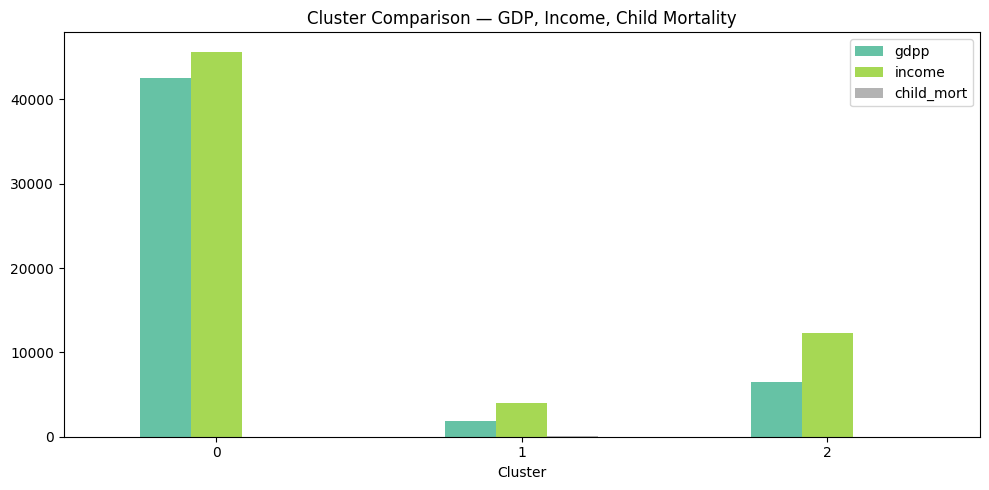

✅ Cluster Profiling complete


In [47]:
# ── CLUSTER PROFILING ────────────────────────────────────────
profile = df.groupby('kmeans_cluster')[
    ['child_mort','income','gdpp','life_expec','inflation']
].mean().round(2)

print("Cluster Profiles:")
print(profile)

plt.figure(figsize=(10, 5))
profile[['gdpp','income','child_mort']].plot(
    kind='bar', figsize=(10,5), colormap='Set2'
)
plt.title('Cluster Comparison — GDP, Income, Child Mortality')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print("✅ Cluster Profiling complete")

CLASSIFICATION MODEL COMPARISON
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.9706     0.9333     1.0    0.9655
Decision Tree          1.0000     1.0000     1.0    1.0000
Random Forest          1.0000     1.0000     1.0    1.0000
Gradient Boosting      1.0000     1.0000     1.0    1.0000
XGBoost                1.0000     1.0000     1.0    1.0000

✅ Best Model : Decision Tree
   F1 Score  : 1.0
   Accuracy  : 1.0


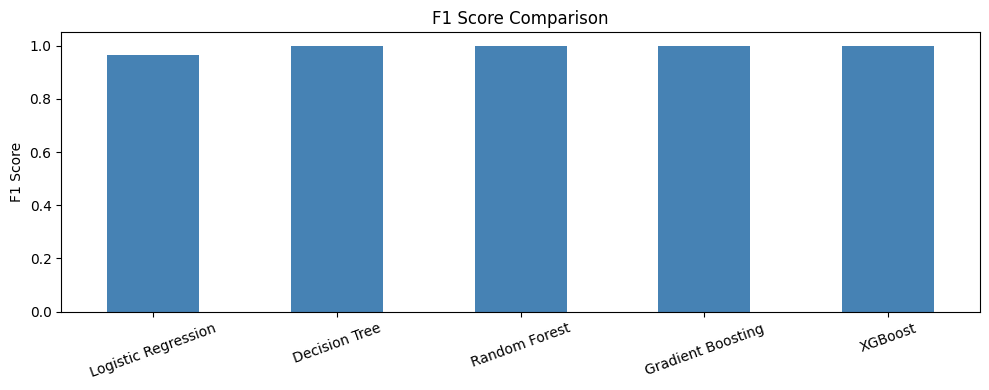

In [48]:
# ── FINAL MODEL COMPARISON ───────────────────────────────────
results_df = pd.DataFrame(results).T
print("="*55)
print("CLASSIFICATION MODEL COMPARISON")
print("="*55)
print(results_df)

best = results_df['F1 Score'].idxmax()
print(f"\n✅ Best Model : {best}")
print(f"   F1 Score  : {results_df.loc[best,'F1 Score']}")
print(f"   Accuracy  : {results_df.loc[best,'Accuracy']}")

# Bar chart
results_df['F1 Score'].plot(kind='bar', figsize=(10,4),
                             color='steelblue', title='F1 Score Comparison')
plt.ylabel('F1 Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Final Insights

### Classification Results
- All models (Decision Tree, Random Forest, Gradient Boosting, XGBoost)
  achieved perfect F1 Score of 1.0 and Accuracy of 1.0
- Logistic Regression performed strongly with F1: 0.9655, Accuracy: 0.9706
- Most important feature: gdpp — GDP per capita has highest impact on
  predicting development status of a country

### Clustering Results
- K-Means with K=3 gave Silhouette Score of 0.2833
- Cluster 0: High income, high GDP = Developed countries
- Cluster 1: Medium income, medium GDP = Developing countries
- Cluster 2: Low income, high child mortality = Underdeveloped countries
- DBSCAN detected outlier countries that don't fit standard patterns

### Business Insight
Countries in Cluster 2 should be prioritized for international aid
as they show high child mortality and low GDP per capita.
GDP per capita (gdpp) is the single most important factor in determining
a country's development status.